In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA

df_orgin = pd.read_csv("data/zigbang_outlier.csv")
df = df_orgin[df_orgin['is_outlier'] == False].copy()
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 843 entries, 0 to 981
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   보증금             843 non-null    int64  
 1   월세              843 non-null    float64
 2   전용면적            843 non-null    float64
 3   노후도             843 non-null    float64
 4   해당층             843 non-null    int64  
 5   전체층             843 non-null    int64  
 6   엘리베이터           843 non-null    bool   
 7   위도              843 non-null    float64
 8   경도              843 non-null    float64
 9   지하철역_거리(m)      843 non-null    float64
 10  세탁소_거리(m)       843 non-null    float64
 11  카페_거리(m)        843 non-null    float64
 12  약국_거리(m)        843 non-null    float64
 13  대형마트_거리(m)      843 non-null    float64
 14  편의점_거리(m)       843 non-null    float64
 15  버스정류장_거리(m)     843 non-null    float64
 16  남향              843 non-null    bool   
 17  풀옵션             843 non-null    bool   


In [3]:
# 3. PCA를 수행할 인프라 거리 컬럼들 선택
infra_cols = [
    '세탁소_거리(m)', '카페_거리(m)', 
    '약국_거리(m)', '대형마트_거리(m)', '편의점_거리(m)'
]

# 4. 데이터 표준화 (PCA 전 필수 단계: 거리 단위가 크기 때문)
scaler = StandardScaler()
infra_scaled = scaler.fit_transform(df[infra_cols])

# 5. Kernel PCA 수행 (n_components=3, kernel='rbf' 사용)
# kernel 옵션: 'rbf', 'poly', 'sigmoid' 등이 있으나 보통 'rbf'가 가장 성능이 좋습니다.
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=None) 
pca_results = kpca.fit_transform(infra_scaled)

# 6. 결과를 데이터프레임에 추가
# Kernel PCA는 explained_variance_ratio_를 지원하지 않으므로 설명력 출력 부분은 제외합니다.
print("✅ Kernel PCA (RBF Kernel) 적용 완료")

# 7. 데이터프레임에 성분 추가 (PC1, PC2, PC3)
for i in range(2):
    df[f'PC{i+1}'] = pca_results[:, i]

df.head()

✅ Kernel PCA (RBF Kernel) 적용 완료


,보증금,월세,전용면적,노후도,해당층,전체층,엘리베이터,위도,경도,지하철역_거리(m),...,약국_거리(m),대형마트_거리(m),편의점_거리(m),버스정류장_거리(m),남향,풀옵션,is_outlier,outlier_reason,PC1,PC2
0,100,35.0,38.00,6.0,2,3,False,35.838980,128.751217,335.0,...,306.0,1565.0,98.0,321.0,True,True,False,NaN,0.137702,-0.421107
1,200,35.0,27.00,6.0,2,4,False,35.839222,128.759495,682.0,...,140.0,2270.0,39.0,105.0,False,True,False,NaN,0.362249,0.406271
2,300,37.0,27.00,6.0,2,4,False,35.839656,128.759237,687.0,...,104.0,2264.0,26.0,51.0,False,True,False,NaN,0.258669,0.496103
4,100,32.0,29.75,6.0,2,4,False,35.822685,128.757263,1563.0,...,318.0,2271.0,130.0,315.0,False,True,False,NaN,0.548271,-0.154822
5,100,30.0,33.06,6.0,4,4,False,35.823191,128.754709,1465.0,...,252.0,2045.0,111.0,252.0,True,True,False,NaN,0.073367,-0.235186


In [4]:
# 5. 학습에 사용할 최종 변수들 선택
features = [
    '보증금', '전용면적', '노후도', '해당층', 
    '엘리베이터', '남향', '풀옵션', 'PC1', 'PC2', '지하철역_거리(m)', '버스정류장_거리(m)']

X = df[features]

# 6. [두 번째 스케일링] 모든 학습 변수를 동일한 선상에 놓기
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

print("✅ 최종 학습용 데이터 정규화(스케일링) 완료!")

✅ 최종 학습용 데이터 정규화(스케일링) 완료!


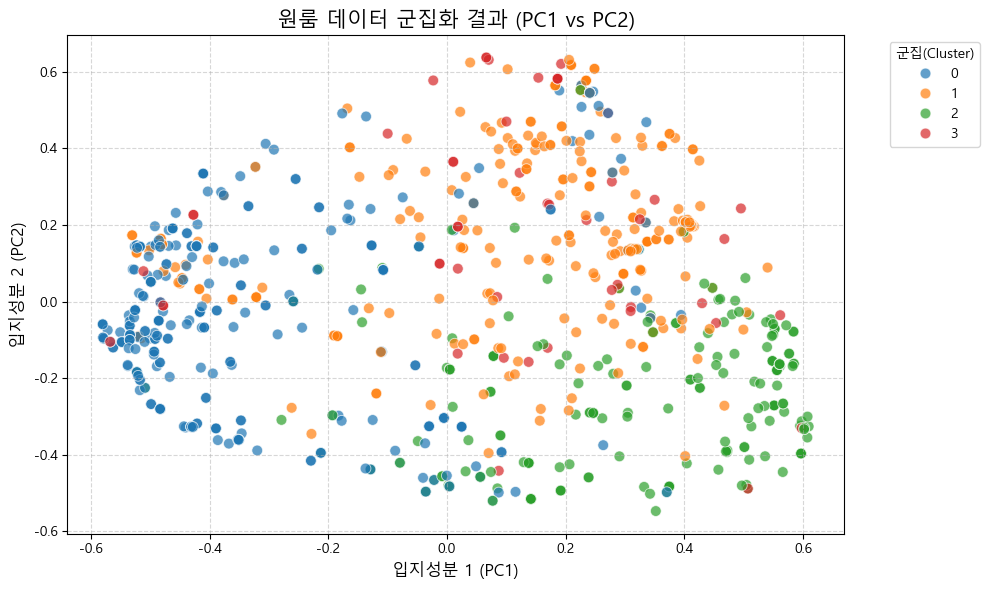

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. K-Means 군집화 (K=3로 설정)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. 산점도 시각화 (PC1, PC2 기준)
plt.figure(figsize=(10, 6))

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

sns.scatterplot(
    data=df, 
    x='PC1', 
    y='PC2', 
    hue='cluster', 
    palette='tab10', 
    alpha=0.7, 
    s=60
)

plt.title('원룸 데이터 군집화 결과 (PC1 vs PC2)', fontsize=15)
plt.xlabel('입지성분 1 (PC1)', fontsize=12)
plt.ylabel('입지성분 2 (PC2)', fontsize=12)
plt.legend(title='군집(Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 분석할 변수들 선택 (인프라 거리, 방 상태, 가격 등)
# 데이터프레임에 있는 컬럼명에 맞춰 조정하세요.
analysis_cols = [
    '보증금', '전용면적', '노후도', '해당층', 
    '엘리베이터', '남향', '풀옵션', 'PC1', 'PC2', '지하철역_거리(m)', '버스정류장_거리(m)', '월세']

# 2. 군집별 평균 계산
cluster_mean = df.groupby('cluster')[analysis_cols].mean()

# 3. 전체 평균 대비 비율 계산 (어떤 군집이 특정 변수에서 '특출난지' 보기 위함)
relative_strength = cluster_mean / df[analysis_cols].mean()

print("🔍 [군집별 전체 평균 대비 특성 (1.0보다 크면 해당 특성이 강함)]")
display(relative_strength.round(2))

# 6. 군집별 한줄 요약 (가이드)
for i in range(len(cluster_mean)):
    print(f"\n✅ 군집 {i}번 프로파일링:")
    row = relative_strength.loc[i]
    traits = []
    if row['월세'] > 1.1: traits.append("상대적으로 고가")
    elif row['월세'] < 0.9: traits.append("가성비 좋음")
    
    if row['전용면적'] > 1.1: traits.append("넓은 방")
    if row['노후도'] < 0.8: traits.append("신축 위주")
    if row['PC1'] > 1.1: traits.append("입지 우수(역세권/편의시설)")
    
    if not traits: traits.append("평균적인 특징")
    print(f"  -> 특징: {', '.join(traits)}")

🔍 [군집별 전체 평균 대비 특성 (1.0보다 크면 해당 특성이 강함)]


,보증금,전용면적,노후도,해당층,엘리베이터,남향,풀옵션,PC1,PC2,지하철역_거리(m),버스정류장_거리(m),월세
cluster,,,,,,,,,,,,
0,1.02,0.89,0.87,1.02,0.00,0.79,1.23,-9.759042e+16,3.292312e+14,0.51,1.03,1.05
1,1.03,1.13,0.91,1.04,0.00,1.23,0.65,4.109965e+16,-2.224227e+15,1.65,0.71,0.96
2,0.85,1.00,1.36,0.87,0.00,1.06,1.14,9.666090e+16,2.983586e+15,0.91,1.37,0.94
3,1.30,1.05,0.88,1.15,16.53,0.96,0.81,3.201801e+16,-2.356145e+15,1.15,0.85,1.09



✅ 군집 0번 프로파일링:
  -> 특징: 평균적인 특징

✅ 군집 1번 프로파일링:
  -> 특징: 넓은 방, 입지 우수(역세권/편의시설)

✅ 군집 2번 프로파일링:
  -> 특징: 입지 우수(역세권/편의시설)

✅ 군집 3번 프로파일링:
  -> 특징: 입지 우수(역세권/편의시설)


In [7]:
# 1. 먼저 원핫 인코딩 수행
df_encoded = pd.get_dummies(df, columns=['cluster'], prefix='cluster')

# 2. 인코딩된 결과를 다시 df에 할당
df = df_encoded

# 3. 이제 df에서 모든 bool 타입을 찾아서 int로 변환 (원핫 인코딩으로 생긴 컬럼들까지 포함됨)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# 4. 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 843 entries, 0 to 981
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   보증금             843 non-null    int64  
 1   월세              843 non-null    float64
 2   전용면적            843 non-null    float64
 3   노후도             843 non-null    float64
 4   해당층             843 non-null    int64  
 5   전체층             843 non-null    int64  
 6   엘리베이터           843 non-null    int64  
 7   위도              843 non-null    float64
 8   경도              843 non-null    float64
 9   지하철역_거리(m)      843 non-null    float64
 10  세탁소_거리(m)       843 non-null    float64
 11  카페_거리(m)        843 non-null    float64
 12  약국_거리(m)        843 non-null    float64
 13  대형마트_거리(m)      843 non-null    float64
 14  편의점_거리(m)       843 non-null    float64
 15  버스정류장_거리(m)     843 non-null    float64
 16  남향              843 non-null    int64  
 17  풀옵션             843 non-null    int64  


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error
# 1. 원핫 인코딩 (Cluster 변수를 펼쳐서 모델이 오해하지 않게 함)

# 2. 학습 변수(X)와 정답(y) 설정
# 사용자가 선택한 모든 변수 + 원핫 인코딩된 클러스터 변수들
features = ['보증금', '전용면적', '노후도', '해당층', '엘리베이터', '남향', '풀옵션', 'PC1', 'PC2', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', '지하철역_거리(m)', '버스정류장_거리(m)']
final_features = features

X = df[final_features]
y = df['월세']

# 3. 학습/테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 앙상블 모델(Voting) 학습
# 3가지 강력한 모델을 결합하여 예측력과 안정성을 극대화합니다.
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42)

voting_model = VotingRegressor(estimators=[('rf', rf), ('gb', gb), ('hgb', hgb)])
voting_model.fit(X_train, y_train)

# 5. 결과 확인
y_pred = voting_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred) # 최신 버전 전용 함수

print(f"📈 최종 모델 R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"📉 최종 모델 MAE (평균 오차): {mean_absolute_error(y_test, y_pred):.2f}만원")
print(f"📏 최종 모델 RMSE (제곱근 오차): {rmse:.2f}만원")

📈 최종 모델 R2 Score: 0.7348
📉 최종 모델 MAE (평균 오차): 2.17만원
📏 최종 모델 RMSE (제곱근 오차): 2.76만원


In [9]:
def predict_my_room(deposit, area, age, floor, elevator, south, option, pc_values, cluster_id, subway, bus):
    # 1. 데이터 구성
    data = {
        '보증금': deposit, 
        '전용면적': area, 
        '노후도': age, 
        '해당층': floor, 
        '엘리베이터': elevator, 
        '남향': south, 
        '풀옵션': option,
        'PC1': pc_values[0], 
        'PC2': pc_values[1], 
        'cluster_0': 1 if cluster_id == 0 else 0,
        'cluster_1': 1 if cluster_id == 1 else 0,
        'cluster_2': 1 if cluster_id == 2 else 0,
        'cluster_3': 1 if cluster_id == 3 else 0,
        '지하철역_거리(m)' : subway,
        '버스정류장_거리(m)' : bus
    }
    
    # 2. 데이터프레임 생성
    sample_df = pd.DataFrame([data])
    
    # [핵심] 학습할 때 사용했던 컬럼 순서(final_features)와 동일하게 재배치
    # final_features 변수가 메모리에 남아있어야 합니다.
    sample_df = sample_df[final_features]
    
    # 3. 예측
    pred = voting_model.predict(sample_df)
    return pred[0]

In [10]:
# 실제 데이터프레임의 0번 행 데이터로 테스트
test_row = df.iloc[30]
pc_test = [test_row['PC1'], test_row['PC2']]
cluster_test = 1 # 예시 군집 번호

real_test_rent = predict_my_room(
    test_row['보증금'], test_row['전용면적'], test_row['노후도'], 
    test_row['해당층'], test_row['엘리베이터'], test_row['남향'], 
    test_row['풀옵션'], pc_test, cluster_test, test_row['지하철역_거리(m)'], test_row['버스정류장_거리(m)']
)
print(f"🏠 실제 보증금 {test_row['보증금']}일 때 예측 월세: {real_test_rent:.1f}만원")
print(f"📊 실제 데이터에 적힌 월세: {test_row['월세']}만원")

🏠 실제 보증금 100일 때 예측 월세: 30.2만원
📊 실제 데이터에 적힌 월세: 30.0만원


In [11]:
import joblib
import os

# 1. 모델을 저장할 폴더 경로 설정 (방금 만드신 폴더명)
# 노트북 파일과 같은 위치에 'room_price_app' 폴더가 있다고 가정합니다.
save_path = 'C:\minwoin\miniproject\predictrent\models'

# 폴더가 없으면 에러가 나므로, 혹시 모르니 안전장치로 생성 코드를 넣습니다.
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. 저장할 모델과 파일명 매칭
# (변수명은 회원님의 마지막 코드 기준입니다)
models_to_save = {
    "voting_model.pkl": voting_model,  # 월세 예측 모델
    "kpca.pkl": kpca,                  # 차원 축소 모델 (KernelPCA)
    "kmeans.pkl": kmeans,              # 군집화 모델
    "scaler_infra.pkl": scaler,        # 인프라 거리 스케일러 (변수명이 scaler였음)
    "scaler_final.pkl": scaler_final   # 학습용 최종 스케일러
}

# 3. 파일로 저장 (dump)
print("💾 모델 저장을 시작합니다...")
for file_name, model_object in models_to_save.items():
    full_path = os.path.join(save_path, file_name)
    joblib.dump(model_object, full_path)
    print(f"  ✅ {file_name} 저장 완료!")

print(f"\n🎉 모든 모델이 '{save_path}' 폴더에 저장되었습니다.")

💾 모델 저장을 시작합니다...
  ✅ voting_model.pkl 저장 완료!
  ✅ kpca.pkl 저장 완료!
  ✅ kmeans.pkl 저장 완료!
  ✅ scaler_infra.pkl 저장 완료!
  ✅ scaler_final.pkl 저장 완료!

🎉 모든 모델이 'C:\minwoin\miniproject\predictrent\models' 폴더에 저장되었습니다.


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\KDT48\AppData\Local\Temp\ipykernel_35052\1315329049.py:6: SyntaxWarning: invalid escape sequence '\m'
  save_path = 'C:\minwoin\miniproject\predictrent\models'
